In [3]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items')  # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='nikhil',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'D:/Study/Data Analytics/Project Ecommerce'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

KeyboardInterrupt: 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector as msc
import numpy as np

db = msc.connect(host='localhost',
    user='root',
    password='nikhil',
    database='ecommerce')

cur = db.cursor() #Activating the cursor


In [2]:
print("hello")

hello


##### Basic Queries
##### 1. List all unique cities where customers are located.


In [6]:
query = """ select distinct customer_city
            from customers"""
cur.execute(query)
data = cur.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

##### 2. Count the number of orders placed in 2017.

In [7]:
query = """ select count(order_id)
            from orders 
            where year(order_purchase_timestamp) = 2017 """
cur.execute(query)
data = cur.fetchall()
"total orders placed in 2017 are: ", data[0][0]

('total orders placed in 2017 are: ', 225505)

##### 3. Find the total sales per category.

In [6]:
query = """ select a.product_category as Category, round(sum(b.payment_value),2) as Sales
            from products as a
            inner join order_items as c
            on a.product_id = c.product_id
            inner join payments as b
            on b.order_id = c.order_id 
            group by a.product_category"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["Category","Sales"])
df

,Category,Sales
0,perfumery,6.334233e+07
1,Furniture Decoration,1.787720e+08
2,telephony,6.086026e+07
3,bed table bath,2.140692e+08
4,automotive,1.065368e+08
...,...,...
69,cds music dvds,1.499288e+05
70,La Cuisine,3.641912e+05
71,Fashion Children's Clothing,9.820875e+04
72,PC Gamer,2.718038e+05


##### 4. Calculate the percentage of orders that were paid in installments.

In [13]:
query = """ select sum(case when payment_installments >1 then 1
            else 0
            end)/count(*)*100 from payments """

cur.execute(query)
data = cur.fetchall()
' percentage of orders that were paid in installments are: ', data

(' percentage of orders that were paid in installments are: ',
 [(Decimal('49.4176'),)])

##### 5. Count the number of customers from each state. 

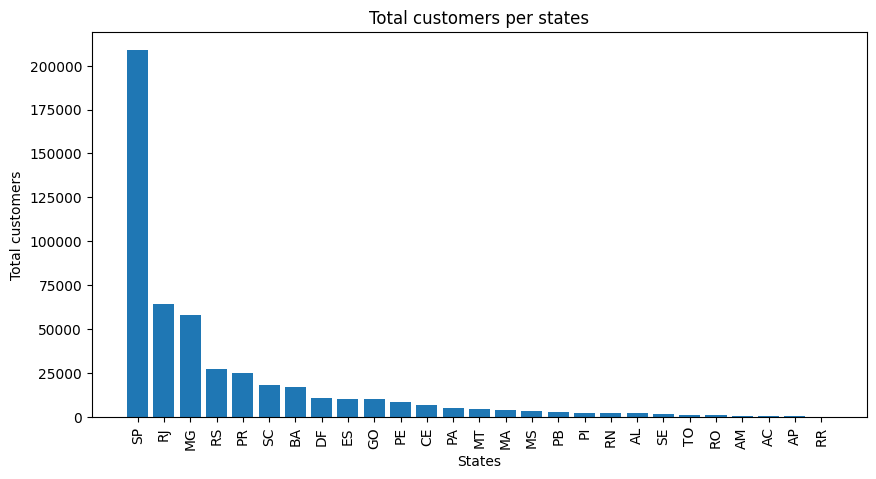

In [15]:
query = """ select customer_state, count(customer_id)
            from customers 
            group by customer_state"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["State", "Total customers"])
df = df.sort_values(by= "Total customers", ascending= False)
df


plt.figure(figsize=(10,5))
plt.bar(df["State"],df["Total customers"])
plt.xticks(rotation = 90)
plt.xlabel("States")
plt.ylabel("Total customers")
plt.title("Total customers per states")
plt.show()

##### Intermediate Queries
##### 1. Calculate the number of orders per month in 2018.

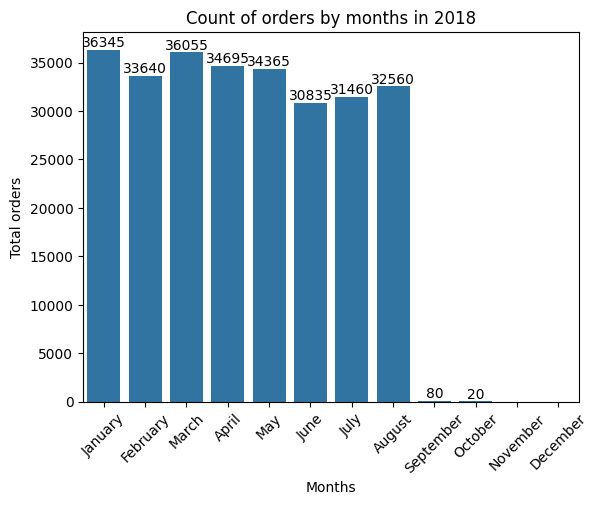

In [23]:
query = """ select monthname(order_purchase_timestamp), count(order_id)
            from orders 
            where year(order_purchase_timestamp) = 2018
            group by monthname(order_purchase_timestamp)"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["Months", "Total orders"])
df

o = ["January","February","March","April","May","June","July","August","September","October","November","December"]
ax = sns.barplot(data = df, x = df["Months"], y = df["Total orders"], order= o )
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("Count of orders by months in 2018")
plt.show()



##### 2. Find the average number of products per order, grouped by customer city.


In [3]:
query = """ select t.customer_city as City, round(avg(total_order),2) as Avg_product_per_order
            from(
                select  a.order_id, c.customer_city, count(b.order_id) as total_order
                from orders as a 
                join order_items as b 
                on a.order_id = b.order_id
                join customers as c 
                on a.customer_id = c.customer_id
                group by a.order_id, c.customer_city
            ) as t
            group by t.customer_city"""

cur.execute(query)
data = cur.fetchall()
data

[('anapolis', Decimal('141.74')),
 ('sao paulo', Decimal('144.53')),
 ('brasilia', Decimal('141.30')),
 ('belo horizonte', Decimal('142.91')),
 ('lagoa santa', Decimal('139.83')),
 ('osasco', Decimal('143.19')),
 ('campo grande', Decimal('142.86')),
 ('rio de janeiro', Decimal('143.35')),
 ('sao luis', Decimal('140.45')),
 ('campos dos goytacazes', Decimal('135.50')),
 ('sao joaquim de bicas', Decimal('156.25')),
 ('sao jose dos campos', Decimal('142.31')),
 ('nova friburgo', Decimal('135.83')),
 ('porto alegre', Decimal('146.87')),
 ('paripueira', Decimal('125.00')),
 ('salvador', Decimal('142.57')),
 ('itaborai', Decimal('133.33')),
 ('atibaia', Decimal('145.70')),
 ('ribeirao preto', Decimal('143.21')),
 ('carmo da mata', Decimal('125.00')),
 ('andorinha', Decimal('125.00')),
 ('alegrete', Decimal('142.86')),
 ('curitiba', Decimal('144.95')),
 ('maua', Decimal('135.58')),
 ('presidente prudente', Decimal('141.41')),
 ('jundiai', Decimal('146.43')),
 ('macae', Decimal('143.46')),
 ('

##### 3. Calculate the percentage of total revenue contributed by each product category.


In [5]:
query = """ select a.product_category as Category, 
            round((sum(b.payment_value)/(select sum(payment_value) from payments))*100,2) as Sales
            from products a
            join order_items as c
            on a.product_id = c.product_id
            inner join payments as b
            on b.order_id = c.order_id 
            group by a.product_category
            order by Sales desc"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["Category","Sales"])
df

,Category,Sales
0,bed table bath,267.44
1,HEALTH BEAUTY,258.82
2,computer accessories,247.57
3,Furniture Decoration,223.34
4,Watches present,223.19
...,...,...
69,PC Gamer,0.34
70,House Comfort 2,0.27
71,cds music dvds,0.19
72,Fashion Children's Clothing,0.12


##### The above query is mistake as the orders can have multiple payments, causing denominato to be inflated or the joins to create duplicate rows.

In [2]:
query = """
WITH category_sales AS (
    SELECT 
        a.product_category AS Category,
        SUM(b.payment_value) AS total_sales
    FROM products a
    JOIN order_items c ON a.product_id = c.product_id
    JOIN payments b ON b.order_id = c.order_id
    GROUP BY a.product_category
)
SELECT 
    Category,
    ROUND((total_sales / SUM(total_sales) OVER()) * 100, 2) AS Sales
FROM category_sales
ORDER BY Sales DESC;
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["Category","Sales"])
df

,Category,Sales
0,bed table bath,8.43
1,HEALTH BEAUTY,8.16
2,computer accessories,7.81
3,Furniture Decoration,7.04
4,Watches present,7.04
...,...,...
69,cds music dvds,0.01
70,La Cuisine,0.01
71,PC Gamer,0.01
72,Fashion Children's Clothing,0.00


##### 4. Identify the correlation between product price and the number of times a product has been purchased.

In [11]:
query = """ select a.product_category, count(b.product_id),
            round(avg(b.price),2)
            from products as a 
            join order_items as b 
            on a.product_id = b.product_id
            group by a.product_category"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["Category", "Order_count", "Price"])

arr1 = df["Order_count"]
arr2 = df["Price"]
np.corrcoef([arr1, arr2])

array([[ 1.        , -0.10631514],
       [-0.10631514,  1.        ]])

##### Note: 
###### Ignore the diagonal value, and though the number is -ve but it is nearly equal to 0, so we can say that, there is no such direct or indirect/inversely relationship and has no relationship or dependencies between them.

##### 5. Calculate the total revenue generated by each seller, and rank them by revenue.

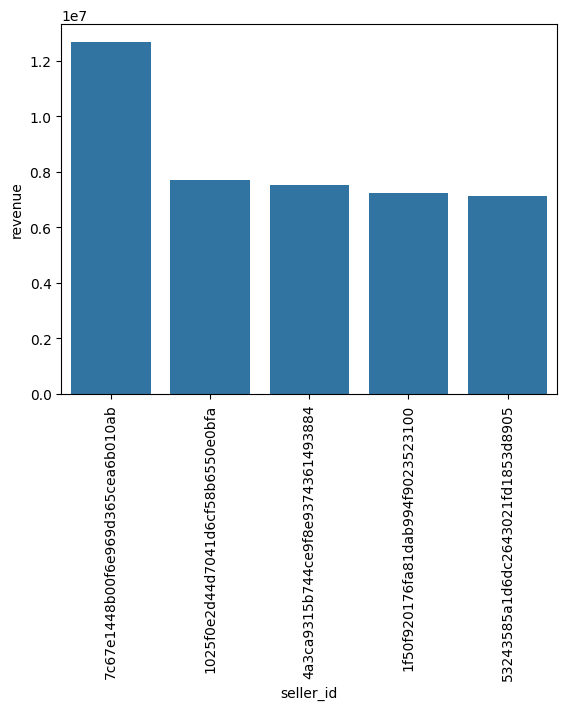

In [26]:
query = """ select *, dense_rank() over(order by revenue desc) as rnk from 
            (select order_items.seller_id, round(sum(payments.payment_value),2) as revenue
            from order_items join payments
            on order_items.order_id = payments.order_id
            group by order_items.seller_id)as a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["seller_id", "revenue", "Rank"])
df = df.head()
sns.barplot(data=df, x="seller_id", y="revenue")
plt.xticks(rotation = 90)
plt.show()

##### Advanced Queries
##### 1. Calculate the moving average of order values for each customer over their order history.

In [29]:
query = """select customer_id, order_purchase_timestamp, payment,
            avg(payment) over(partition by customer_id 
                              order by order_purchase_timestamp
                              rows between 2 preceding and current row) as mov_avg 
            from
            (select orders.customer_id, orders.order_purchase_timestamp, 
            p.total_payment as payment
            from orders join(
                                select order_id, sum(payment_value) as total_payment
                                from payments
                                group by order_id
                            ) as p
            on p.order_id = orders.order_id) as a"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["Customer_id", "Timestamp", "Payment", "Moving average"])
df

,Customer_id,Timestamp,Payment,Moving average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,573.699989,573.699989
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,573.699989,573.699989
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,573.699989,573.699989
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,573.699989,573.699989
4,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,573.699989,573.699989
...,...,...,...,...
596635,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,91.850004,91.850004
596636,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,91.850004,91.850004
596637,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,91.850004,91.850004
596638,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,91.850004,91.850004


##### Note: Here the rows are getting repeated, in order to avoid it 
##### Problem 1 — Timestamp had time component:
##### order_purchase_timestamp stores date AND time like 2018-01-01 12:35:00, so even ##### same-day orders looked different. Wrapping it in DATE() strips the time part and ##### treats them as the same day.
##### Problem 2 — Multiple orders per customer on same date:
##### After fixing timestamps, if a customer had 2 orders on the same day they'd still ##### show as 2 rows. The outer GROUP BY customer_id, DATE(...) collapses them into one ##### row with summed payment.
##### Problem 3 — No ORDER BY in final output:
##### Added ORDER BY customer_id, order_purchase_timestamp so results are clean and ##### readable, and the moving average makes chronological sense.

In [30]:
query = """
SELECT customer_id, order_purchase_timestamp, payment,
       AVG(payment) OVER(
           PARTITION BY customer_id 
           ORDER BY order_purchase_timestamp
           ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
       ) AS mov_avg 
FROM (
    SELECT o.customer_id, 
           DATE(o.order_purchase_timestamp) as order_purchase_timestamp,  
           SUM(p.total_payment) as payment         -- sum in case same customer has multiple orders on same date
    FROM orders o
    JOIN (
        SELECT order_id, SUM(payment_value) AS total_payment
        FROM payments
        GROUP BY order_id
    ) AS p ON p.order_id = o.order_id
    GROUP BY o.customer_id, DATE(o.order_purchase_timestamp)  -- group by customer + date to avoid duplicates
) AS a
ORDER BY customer_id, order_purchase_timestamp
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["Customer_id", "Timestamp", "Payment", "Moving Average"])
df

,Customer_id,Timestamp,Payment,Moving Average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14,3442.199936,3442.199936
1,000161a058600d5901f007fab4c27140,2017-07-16,2022.300110,2022.300110
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28,5862.599945,5862.599945
3,0002414f95344307404f0ace7a26f1d5,2017-08-16,5380.500183,5380.500183
4,000379cdec625522490c315e70c7a9fb,2018-04-02,3210.300064,3210.300064
...,...,...,...,...
99435,fffecc9f79fd8c764f843e9951b11341,2018-03-29,2440.800093,2440.800093
99436,fffeda5b6d849fbd39689bb92087f431,2018-05-22,1893.900032,1893.900032
99437,ffff42319e9b2d713724ae527742af25,2018-06-13,6423.900146,6423.900146
99438,ffffa3172527f765de70084a7e53aae8,2017-09-02,1365.000000,1365.000000


##### 2. Calculate the cumulative sales per month for each year.

In [13]:
query = """ select years, months, payment, 
            sum(payment) over(order by years, months) as cummulative_sales from
            (select year(o.order_purchase_timestamp) as years, 
            month(o.order_purchase_timestamp) as months,
            round(sum(p.payment_value),2) as payment
            from orders as o
            join payments as p
            on o.order_id = p.order_id
            group by years, months) as a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["years", "months", "payments", "cummulative_sales"])
pd.set_option("display.float_format", lambda x: "%.2f" % x)
df


,years,months,payments,cummulative_sales
0,2016,9,7567.20,7567.20
1,2016,10,1772714.40,1780281.60
2,2016,12,588.60,1780870.20
3,2017,1,4154641.20,5935511.40
4,2017,2,8757240.29,14692751.69
5,2017,3,13495907.99,28188659.68
6,2017,4,12533640.88,40722300.56
7,2017,5,17787564.60,58509865.16
8,2017,6,15338291.41,73848156.57
9,2017,7,17771487.58,91619644.15


##### 3. Calculate the year-over-year growth rate of total sales.

In [6]:
query = """select years, payment,
            lag(payment) over(order by years) as previous_sales,
            (payment- lag(payment,1) over(order by years))/lag(payment, 1)over(order by years)*100
            from
            (select year(o.order_purchase_timestamp) as years, 
            round(sum(p.payment_value),2) as payment
            from orders as o
            join payments as p
            on o.order_id = p.order_id
            group by years) as a"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=["years", "total sales", "previous year sale", "yoy % growth"])
pd.set_option("display.float_format", lambda x: "%.2f" % x)
df

,years,total sales,previous year sale,yoy % growth
0,2016,1780870.20,NaN,NaN
1,2017,217492401.85,1780870.20,12112.70
2,2018,260992891.56,217492401.85,20.00


##### 4. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [9]:
query = """with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < date_add(first_order, interval 6 month)
group by a.customer_id)

select (count(distinct b.customer_id)/count(distinct a.customer_id))*100
from a left join b 
on a.customer_id = b.customer_id"""

cur.execute(query)
data =  cur.fetchall()
data

[(Decimal('0.0000'),)]

##### Note: Here left join is used because a gives total customers and b only gives the selected customers who came back, and for calculating the percentage we need (customers who returned ie. b.customers_id)/(total customers a.customers_id)*100 but in our case, since no one returned it is 0.

##### 5. Identify the top 3 customers who spent the most money in each year.

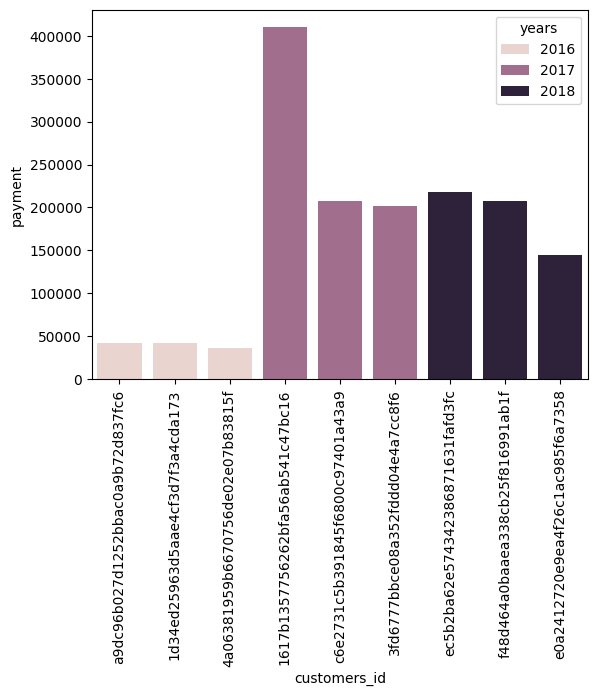

In [12]:
query = """select years, customers, payment, d_rank
from
(select year(orders.order_purchase_timestamp) as years, orders.customer_id as customers,
sum(payments.payment_value) as payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
				  order by sum(payments.payment_value) desc) as d_rank
from orders join payments 
on orders.order_id = payments.order_id
group by year(orders.order_purchase_timestamp), orders.customer_id) as a
where d_rank <= 3;"""
cur.execute(query)
data =  cur.fetchall()
df = pd.DataFrame(data, columns= ["years", "customers_id", "payment", "rank"])
sns.barplot(data = df, x= "customers_id", y = "payment", hue = "years" )
plt.xticks(rotation = 90)
plt.show()